DATASET              | SPLIT    | KATEGORI        | JUMLAH
----------------------------------------------------------------------
dataset_jenis_buah   | train    | apples          | 2071 file
dataset_jenis_buah   | train    | banana          | 2080 file
dataset_jenis_buah   | train    | oranges         | 2157 file
dataset_jenis_buah   | test     | apples          | 500 file
dataset_jenis_buah   | test     | banana          | 505 file
dataset_jenis_buah   | test     | oranges         | 500 file
dataset_kematangan_buah | train    | overripe        | 504 file
dataset_kematangan_buah | train    | ripe            | 960 file
dataset_kematangan_buah | train    | unripe          | 877 file
dataset_kematangan_buah | test     | overripe        | 100 file
dataset_kematangan_buah | test     | ripe            | 100 file
dataset_kematangan_buah | test     | unripe          | 100 file
dataset_kesegaran_buah | train    | fresh           | 4740 file
dataset_kesegaran_buah | train    | unfresh         |

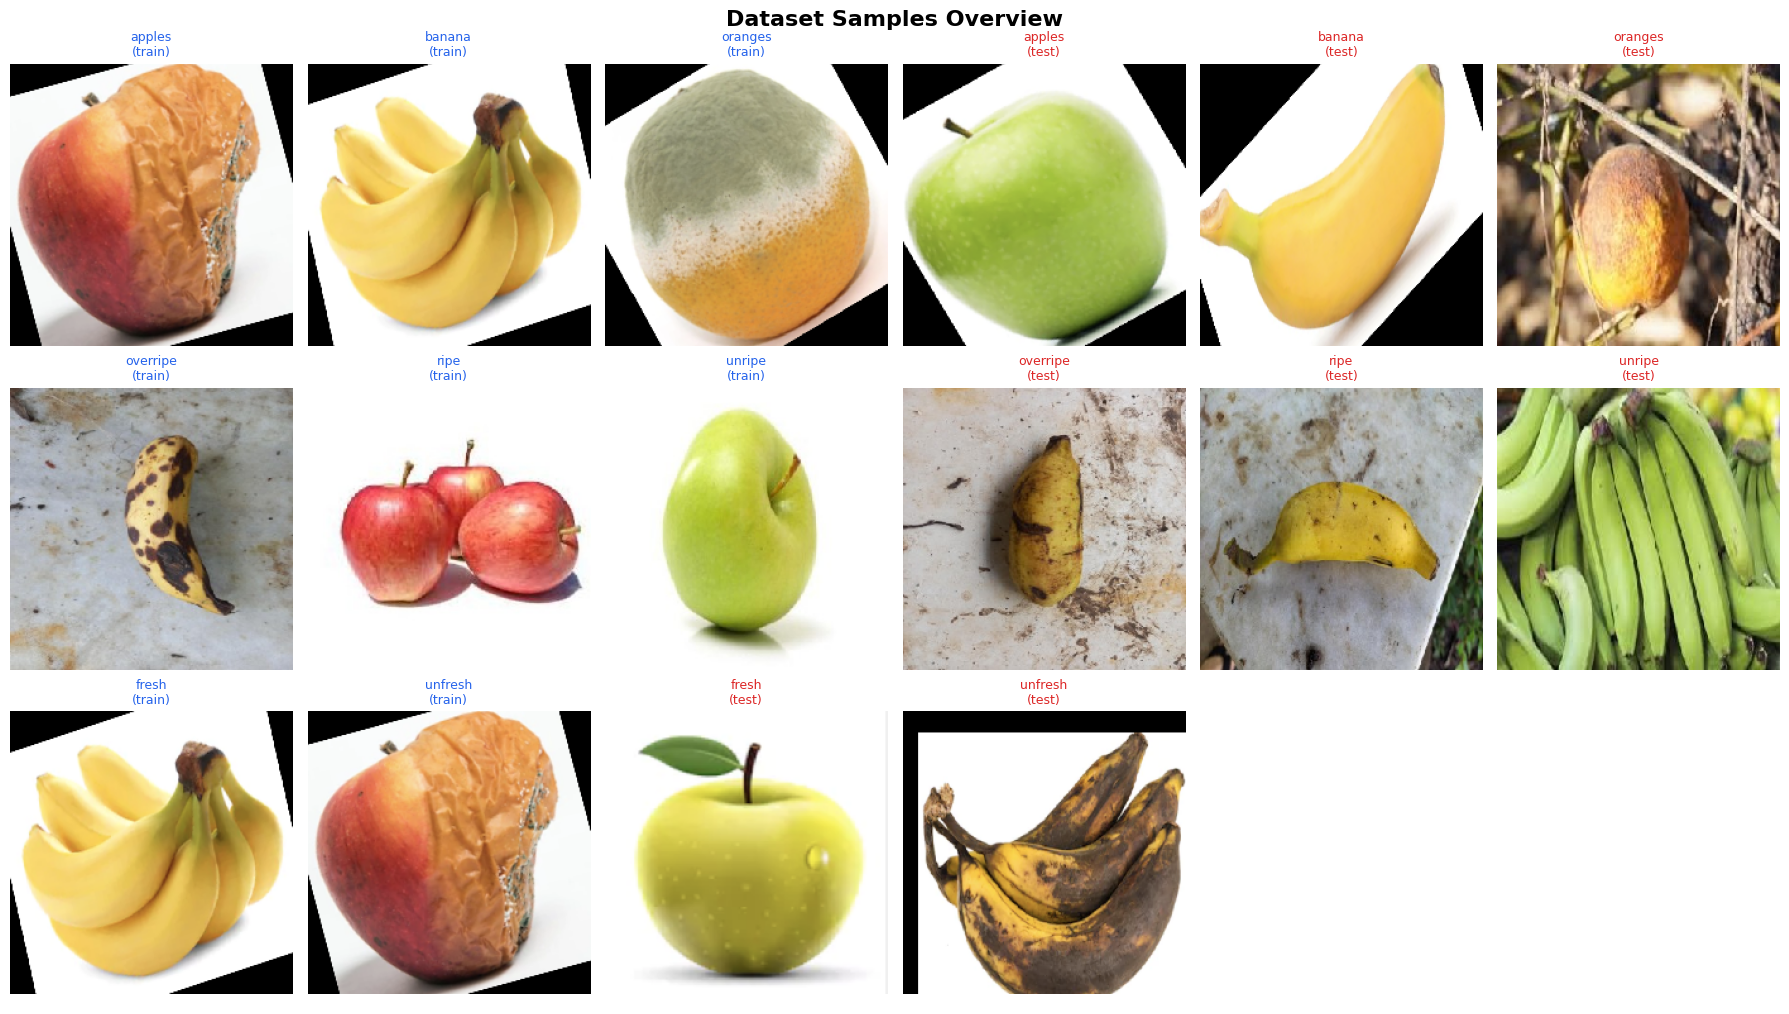

In [2]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd

base_path = 'master_dataset'
datasets = ['dataset_jenis_buah', 'dataset_kematangan_buah', 'dataset_kesegaran_buah']

stats_data = []
dataset_samples = {}
grand_total = 0

print("="*70)
print(f"{'DATASET':<20} | {'SPLIT':<8} | {'KATEGORI':<15} | {'JUMLAH'}")
print("-" * 70)

for ds in datasets:
    ds_path = os.path.join(base_path, ds)
    if not os.path.exists(ds_path):
        continue
    
    dataset_samples[ds] = {'train': [], 'test': []}
        
    for split in ['train', 'test']:
        split_path = os.path.join(ds_path, split)
        if not os.path.exists(split_path):
            continue
            
        categories = [f for f in os.listdir(split_path) 
                      if os.path.isdir(os.path.join(split_path, f)) and not f.startswith('.')]
        categories.sort()
        
        for cat in categories:
            cat_path = os.path.join(split_path, cat)
            images = [img for img in os.listdir(cat_path) if not img.startswith('.')]
            count = len(images)
            grand_total += count
            
            stats_data.append({
                'Dataset': ds,
                'Split': split,
                'Kategori': cat,
                'Jumlah': count
            })
            print(f"{ds:<20} | {split:<8} | {cat:<15} | {count} file")
            
            if count > 0:
                dataset_samples[ds][split].append((cat, os.path.join(cat_path, images[0])))

print("-" * 70)
print(f"{'TOTAL KESELURUHAN GAMBAR PROYEK':<46} | {grand_total} file")
print("="*70)

fig, axes = plt.subplots(3, 6, figsize=(18, 10))

dataset_order = ['dataset_jenis_buah', 'dataset_kematangan_buah', 'dataset_kesegaran_buah']
sample_idx = 0

for row_idx, ds in enumerate(dataset_order):
    if ds not in dataset_samples:
        continue
    
    train_samples = dataset_samples[ds]['train']
    test_samples = dataset_samples[ds]['test']
    all_samples = train_samples + test_samples
    train_count = len(train_samples)
    
    axes[row_idx, 0].set_ylabel(ds.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    
    for i in range(6):
        ax = axes[row_idx, i]
        if i < len(all_samples):
            cat, path = all_samples[i]
            img = tf.keras.utils.load_img(path, target_size=(224, 224))
            ax.imshow(img)
            if i < train_count:
                ax.set_title(f"{cat}\n(train)", fontsize=9, color='#2563EB')
            else:
                ax.set_title(f"{cat}\n(test)", fontsize=9, color='#DC2626')
        ax.axis('off')

plt.tight_layout()
plt.suptitle("Dataset Samples Overview", fontsize=16, fontweight='bold', y=1.01)
plt.show()

[SUCCESS] Gambar perbandingan PCD berhasil disimpan sebagai: dataset_showing.png


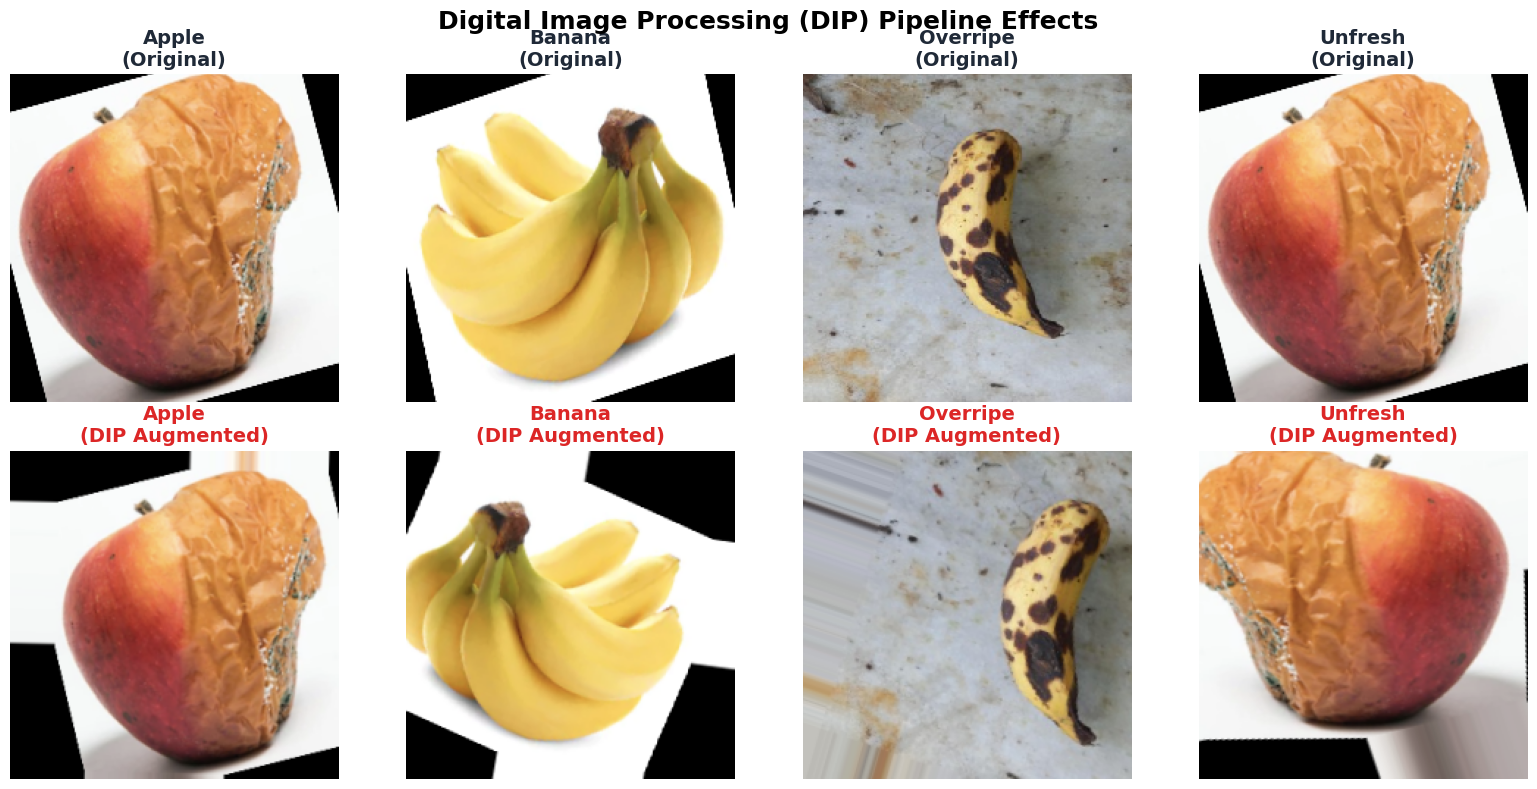

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator

# 1. Konfigurasi Parameter PCD (Harus sama persis dengan klaim di paper Subbab 2.3)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest' # Boundary interpolation mechanism
)

# 2. Tentukan folder sampel (mewakili Variety, Ripeness, dan Freshness)
base_path = 'master_dataset'
sample_folders = [
    ('dataset_jenis_buah/train/apples', 'Apple\n(Original)'),
    ('dataset_jenis_buah/train/banana', 'Banana\n(Original)'),
    ('dataset_kematangan_buah/train/overripe', 'Overripe\n(Original)'),
    ('dataset_kesegaran_buah/train/unfresh', 'Unfresh\n(Original)')
]

# Siapkan grid plot (2 Baris: Original vs Augmented, 4 Kolom)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (folder_path, title) in enumerate(sample_folders):
    full_path = os.path.join(base_path, folder_path)
    
    # Ambil 1 gambar pertama yang valid dari folder tersebut
    if os.path.exists(full_path):
        img_name = [f for f in os.listdir(full_path) if not f.startswith('.')][0]
        img_path = os.path.join(full_path, img_name)
        
        # A. TAHAP 1: Spatial Resampling (Orisinal 224x224)
        img_original = load_img(img_path, target_size=(224, 224))
        
        # Plot Baris 1 (Original)
        axes[0, i].imshow(img_original)
        axes[0, i].set_title(title, fontsize=14, fontweight='bold', color='#1F2937')
        axes[0, i].axis('off')
        
        # B. TAHAP 2: Affine & Geometric Transformation (PCD)
        x = img_to_array(img_original)
        x = np.expand_dims(x, axis=0) # Ubah ke bentuk tensor (1, 224, 224, 3)
        
        # Generate 1 gambar augmented dari generator
        aug_iter = datagen.flow(x, batch_size=1)
        img_augmented = next(aug_iter)[0].astype('uint8')
        
        # Plot Baris 2 (Augmented)
        aug_title = title.replace('Original', 'DIP Augmented')
        axes[1, i].imshow(img_augmented)
        axes[1, i].set_title(aug_title, fontsize=14, fontweight='bold', color='#DC2626')
        axes[1, i].axis('off')

# Rapikan layout
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle("Digital Image Processing (DIP) Pipeline Effects", fontsize=18, fontweight='bold')

# 3. Simpan otomatis untuk LaTeX
save_path = 'dataset_showing.png'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"[SUCCESS] Gambar perbandingan PCD berhasil disimpan sebagai: {save_path}")

plt.show()

[SUCCESS] Gambar perbandingan PCD semua kelas berhasil disimpan sebagai: dataset_showing.png


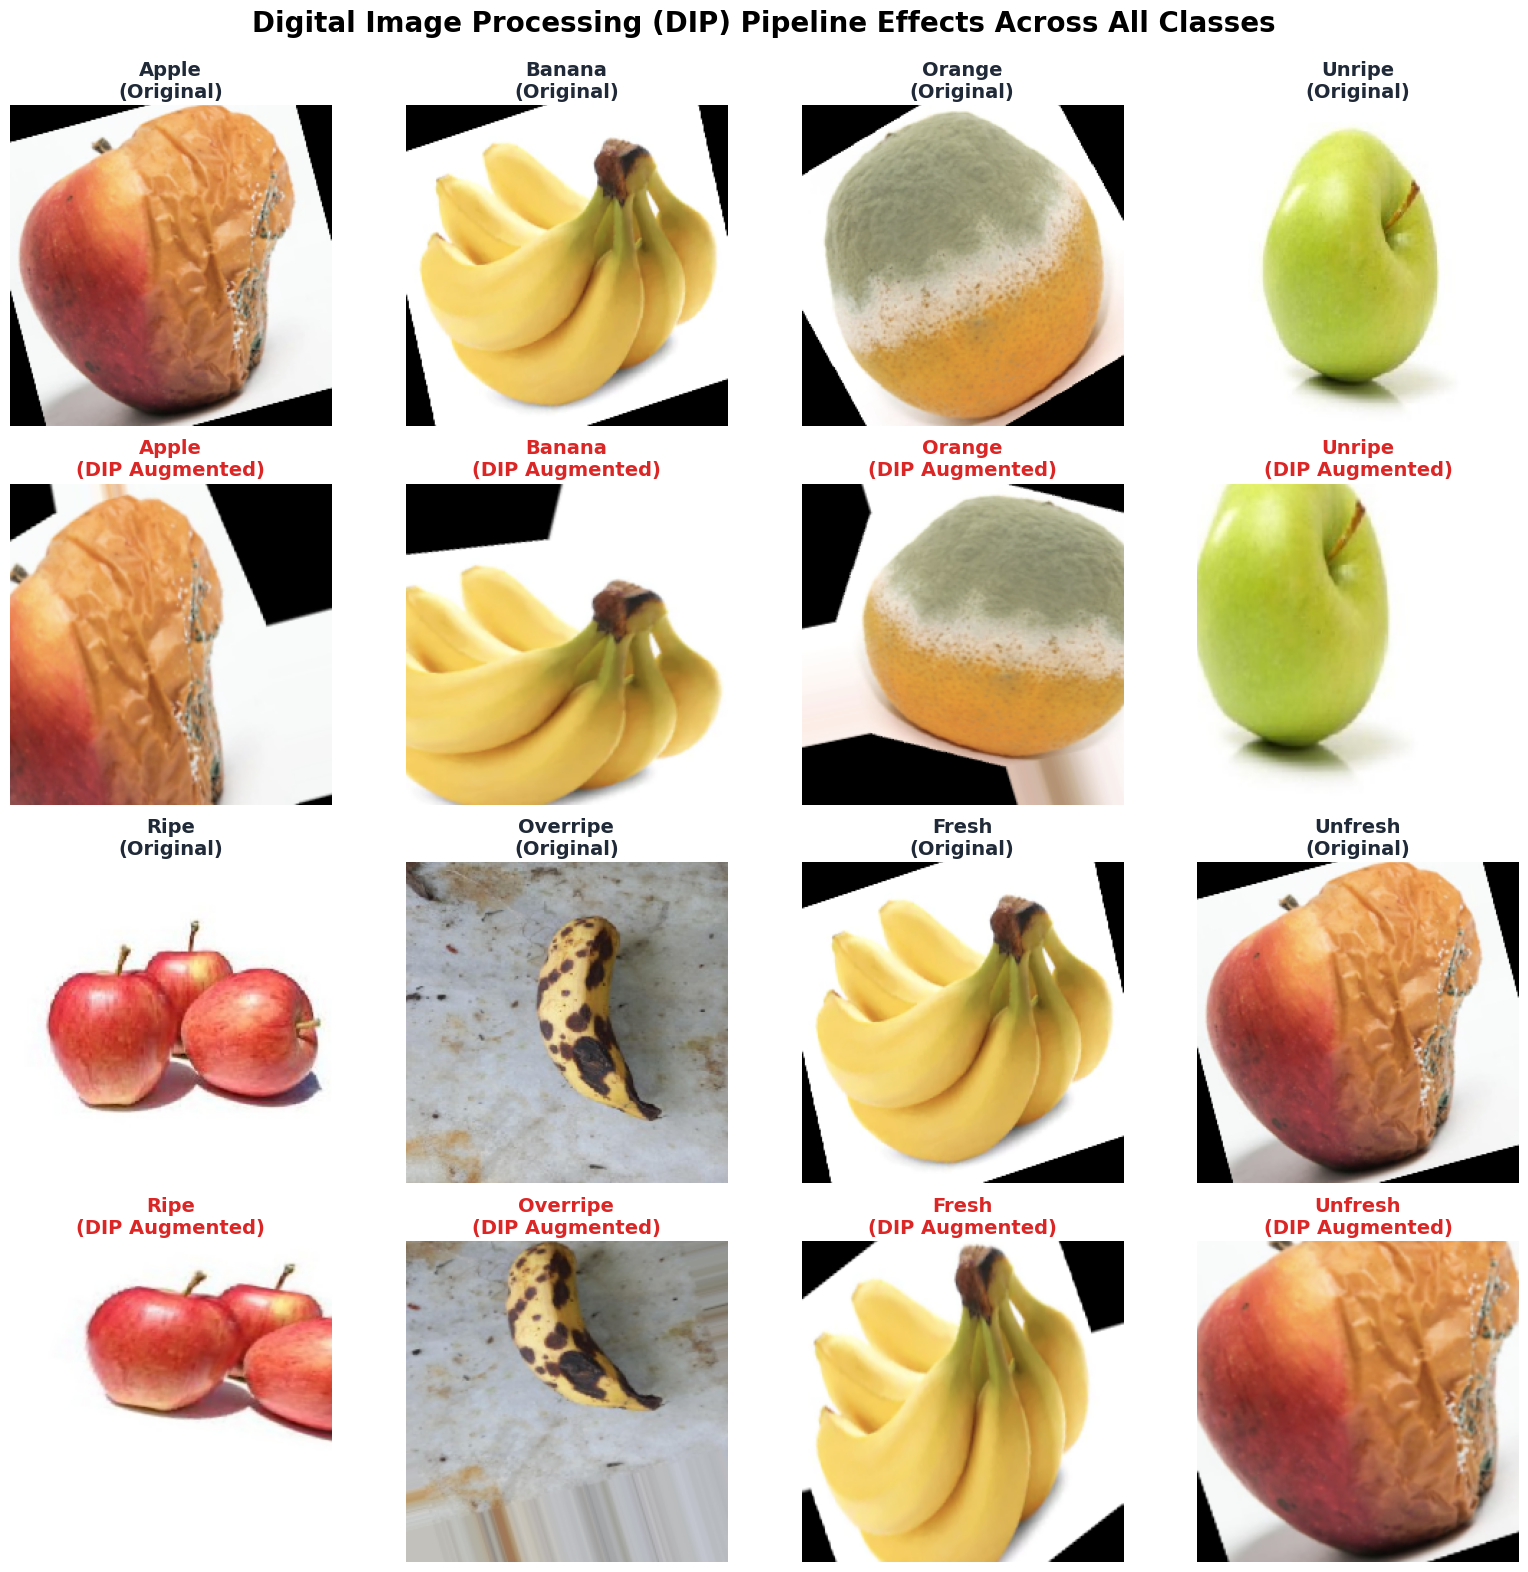

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator

# 1. Konfigurasi Parameter PCD (Klaim di paper Subbab 2.3)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

base_path = 'master_dataset'

# 2. Definisikan SEMUA 8 kategori secara lengkap
all_classes = [
    ('dataset_jenis_buah/train/apples', 'Apple'),
    ('dataset_jenis_buah/train/banana', 'Banana'),
    ('dataset_jenis_buah/train/oranges', 'Orange'),
    ('dataset_kematangan_buah/train/unripe', 'Unripe'),
    ('dataset_kematangan_buah/train/ripe', 'Ripe'),
    ('dataset_kematangan_buah/train/overripe', 'Overripe'),
    ('dataset_kesegaran_buah/train/fresh', 'Fresh'),
    ('dataset_kesegaran_buah/train/unfresh', 'Unfresh')
]

# Siapkan grid plot (4 Baris, 4 Kolom)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i, (folder_path, class_name) in enumerate(all_classes):
    full_path = os.path.join(base_path, folder_path)
    
    # Menentukan posisi grid (Baris dan Kolom)
    # 4 kelas pertama di baris 0 (orig) & baris 1 (aug)
    # 4 kelas kedua di baris 2 (orig) & baris 3 (aug)
    col = i % 4
    row_orig = 0 if i < 4 else 2
    row_aug = 1 if i < 4 else 3
    
    if os.path.exists(full_path):
        img_name = [f for f in os.listdir(full_path) if not f.startswith('.')][0]
        img_path = os.path.join(full_path, img_name)
        
        # --- ORIGINAL ---
        img_original = load_img(img_path, target_size=(224, 224))
        axes[row_orig, col].imshow(img_original)
        axes[row_orig, col].set_title(f"{class_name}\n(Original)", fontsize=14, fontweight='bold', color='#1F2937')
        axes[row_orig, col].axis('off')
        
        # --- AUGMENTED (PCD) ---
        x = img_to_array(img_original)
        x = np.expand_dims(x, axis=0)
        
        aug_iter = datagen.flow(x, batch_size=1)
        img_augmented = next(aug_iter)[0].astype('uint8')
        
        axes[row_aug, col].imshow(img_augmented)
        axes[row_aug, col].set_title(f"{class_name}\n(DIP Augmented)", fontsize=14, fontweight='bold', color='#DC2626')
        axes[row_aug, col].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("Digital Image Processing (DIP) Pipeline Effects Across All Classes", fontsize=20, fontweight='bold')

save_path = 'dataset_showing.png'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"[SUCCESS] Gambar perbandingan PCD semua kelas berhasil disimpan sebagai: {save_path}")

plt.show()